# Laporan Proyek Machine Learning - William

**Proyek Akhir: Membuat Model Sistem Rekomendasi — Rekomendasi Film**

Notebook ini mendokumentasikan alur proyek machine learning secara utuh, mulai dari
*project overview*, *business understanding*, *data understanding*, *data preparation*,
*modeling and result*, hingga *evaluation*. Setiap tahapan dijelaskan melalui text cell dan
diimplementasikan pada code cell di bawahnya, dengan urutan yang sama seperti pada laporan
Markdown yang menyertai submission ini.

Dua pendekatan sistem rekomendasi dibangun dan dibandingkan:

1. **Content-Based Filtering** — merekomendasikan film berdasarkan kemiripan konten (genre).
2. **Collaborative Filtering** — merekomendasikan film berdasarkan pola rating antar pengguna
   melalui *matrix factorization* (SVD).


## Domain Proyek

### Latar Belakang

Industri layanan streaming film menghadapi persoalan yang oleh para peneliti disebut sebagai
*long tail*: katalog yang tersedia sangat besar, tetapi perhatian pengguna terkonsentrasi pada
segelintir judul populer. Pada dataset yang digunakan dalam proyek ini, 10% film terpopuler
menyerap mayoritas dari seluruh rating yang tercatat. Akibatnya, pengguna dihadapkan pada
*information overload* — terlalu banyak pilihan, terlalu sedikit panduan — sementara sebagian
besar katalog tidak pernah tersentuh.

Sistem rekomendasi hadir sebagai jawaban atas persoalan tersebut. Alih-alih meminta pengguna
menelusuri ribuan judul, sistem mempelajari preferensi mereka dari riwayat interaksi, lalu
menyajikan sejumlah kecil kandidat yang paling relevan. Ricci, Rokach, dan Shapira (2015)
menempatkan sistem rekomendasi sebagai komponen yang tidak terpisahkan dari platform modern
karena kemampuannya menurunkan biaya pencarian (*search cost*) sekaligus meningkatkan keterlibatan
pengguna.

### Mengapa dan Bagaimana Masalah Ini Harus Diselesaikan

Masalah ini penting untuk diselesaikan karena dampaknya terukur pada dua sisi sekaligus. Bagi
pengguna, rekomendasi yang relevan mempersingkat waktu yang dibutuhkan untuk menemukan tontonan
yang sesuai. Bagi penyedia layanan, rekomendasi yang baik meningkatkan jumlah film yang
ditonton per sesi, memperpanjang masa berlangganan, dan membuka eksposur bagi judul-judul
non-populer yang sebelumnya tidak terlihat.

Pendekatannya adalah membangun dua model rekomendasi dengan asumsi kerja yang berbeda.
*Content-based filtering* memanfaatkan atribut film (genre) sehingga mampu merekomendasikan
judul baru yang belum memiliki rating sama sekali — mengatasi *item cold-start*. *Collaborative
filtering* memanfaatkan matriks rating pengguna-film sehingga mampu menangkap preferensi yang
tidak terlihat dari atribut film. Kedua model dievaluasi dengan metrik yang sama agar
perbandingannya sahih, kemudian model terbaik dipilih berdasarkan hasil kuantitatif tersebut.

### Referensi

1. Ricci, F., Rokach, L., & Shapira, B. (2015). Recommender systems: Introduction and challenges.
   In *Recommender Systems Handbook* (pp. 1–34). Springer.
2. Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender
   systems. *Computer*, 42(8), 30–37.
3. Lops, P., de Gemmis, M., & Semeraro, G. (2011). Content-based recommender systems: State of
   the art and trends. In *Recommender Systems Handbook* (pp. 73–105). Springer.
4. Sarwar, B., Karypis, G., Konstan, J., & Riedl, J. (2001). Item-based collaborative filtering
   recommendation algorithms. In *Proceedings of the 10th International Conference on World Wide
   Web* (pp. 285–295).
5. Harper, F. M., & Konstan, J. A. (2015). The MovieLens datasets: History and context.
   *ACM Transactions on Interactive Intelligent Systems*, 5(4), 1–19.


## Business Understanding

### Problem Statements

- **Pernyataan Masalah 1:** Bagaimana memanfaatkan atribut konten film (genre) untuk
  merekomendasikan film yang relevan bagi seorang pengguna, termasuk untuk film yang belum
  pernah diberi rating oleh siapa pun?
- **Pernyataan Masalah 2:** Bagaimana memanfaatkan pola rating historis seluruh pengguna untuk
  memprediksi rating yang akan diberikan seorang pengguna pada film yang belum ia tonton?
- **Pernyataan Masalah 3:** Pendekatan mana — *content-based filtering* atau *collaborative
  filtering* — yang memberikan kinerja lebih baik pada dataset ini, dan atas dasar apa pilihan
  tersebut diambil?

### Goals

- **Jawaban Pernyataan Masalah 1:** Membangun model *content-based filtering* yang merepresentasikan
  film sebagai vektor fitur genre dan mengukur kemiripan antar film, sehingga mampu menghasilkan
  daftar top-N rekomendasi personal untuk setiap pengguna.
- **Jawaban Pernyataan Masalah 2:** Membangun model *collaborative filtering* berbasis *matrix
  factorization* yang menguraikan matriks rating pengguna-film menjadi faktor laten, sehingga
  mampu mengestimasi rating pada pasangan pengguna-film yang belum teramati.
- **Jawaban Pernyataan Masalah 3:** Mengevaluasi kedua model dengan metrik yang sama
  (RMSE, MAE, dan Precision@10), membandingkan hasilnya secara kuantitatif, lalu memilih model
  terbaik beserta alasan pemilihannya.

### Solution statements

Untuk mencapai goals di atas, diajukan dua solusi yang masing-masing dapat diukur dengan metrik
evaluasi:

1. **Content-Based Filtering (TF-IDF + Cosine Similarity).** Setiap film direpresentasikan sebagai
   vektor TF-IDF dari genre-nya. Tingkat kemiripan antar film dihitung dengan *cosine similarity*.
   Rating diprediksi sebagai rata-rata berbobot rating pengguna pada film-film yang paling mirip
   secara konten. Diukur dengan **RMSE**, **MAE**, dan **Precision@10**.
2. **Collaborative Filtering (Matrix Factorization / SVD).** Matriks rating yang telah dinormalisasi
   terhadap rata-rata pengguna difaktorkan menjadi matriks laten pengguna dan film berukuran
   `k = 50` menggunakan *truncated SVD*. Rating diprediksi dari hasil kali faktor laten kedua
   pihak. Diukur dengan **RMSE**, **MAE**, dan **Precision@10**.

Kedua solusi menghasilkan *top-N recommendation* sebagai keluaran akhir dan dievaluasi pada
himpunan data uji yang identik, sehingga perbandingannya bersifat *apples-to-apples*.


## Data Understanding

Dataset yang digunakan adalah **MovieLens Latest Small**, dikelola oleh GroupLens Research,
University of Minnesota. Dataset ini berisi rating film yang diberikan oleh pengguna nyata dan
merupakan salah satu *benchmark* paling umum dalam penelitian sistem rekomendasi
(Harper & Konstan, 2015).

**Tautan unduh:** https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

Dataset terdiri atas dua berkas yang digunakan dalam proyek ini:

- `ratings.csv` — pasangan pengguna-film beserta nilai rating.
- `movies.csv` — metadata film: judul dan genre.

Sel berikut memuat dataset dan memeriksa kondisi awalnya.


In [1]:
%matplotlib inline

import json
import os
import shutil
import ssl
import urllib.request
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = "ml-latest-small"
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

# Unduh otomatis bila berkas belum tersedia, agar notebook tetap dapat dijalankan ulang
# oleh reviewer tanpa langkah manual.
if not os.path.exists(os.path.join(DATA_DIR, "ratings.csv")):
    try:  # beberapa instalasi Python tidak punya CA bawaan; certifi menyediakannya
        import certifi

        ctx = ssl.create_default_context(cafile=certifi.where())
    except ImportError:
        ctx = ssl.create_default_context()
    with urllib.request.urlopen(DATA_URL, context=ctx) as resp, open("ml-latest-small.zip", "wb") as fp:
        shutil.copyfileobj(resp, fp)
    with zipfile.ZipFile("ml-latest-small.zip") as z:
        z.extractall(".")

ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
movies = pd.read_csv(os.path.join(DATA_DIR, "movies.csv"))

print("Ukuran ratings :", ratings.shape)
print("Ukuran movies  :", movies.shape)
ratings.head()

Ukuran ratings : (100836, 4)
Ukuran movies  : (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### Variabel-variabel pada MovieLens Latest Small dataset adalah sebagai berikut:

**`ratings.csv`**

- `userId` : identitas unik pengguna yang memberikan rating. Bertipe numerik diskret dan
  digunakan sebagai salah satu sumbu matriks rating.
- `movieId` : identitas unik film yang diberi rating. Menjadi kunci penghubung ke `movies.csv`.
- `rating` : nilai rating yang diberikan pengguna, berskala 0.5–5.0 dengan kelipatan 0.5.
  Inilah variabel target yang diprediksi oleh model *collaborative filtering*.
- `timestamp` : waktu pemberian rating dalam format *Unix epoch*. Tidak digunakan dalam
  pemodelan karena proyek ini tidak menangani aspek temporal.

**`movies.csv`**

- `movieId` : identitas unik film, kunci penghubung ke `ratings.csv`.
- `title` : judul film beserta tahun rilis. Digunakan hanya untuk menampilkan hasil rekomendasi
  agar dapat dibaca manusia.
- `genres` : daftar genre film yang dipisahkan karakter `|`, misalnya
  `Adventure|Animation|Children|Comedy|Fantasy`. Variabel inilah yang menjadi fitur konten pada
  model *content-based filtering*.


In [2]:
print("=== Informasi ratings ===")
ratings.info()
print("\n=== Statistik deskriptif ratings ===")
print(ratings.describe().T.to_string())
print("\n=== Nilai kosong per kolom ===")
print(ratings.isnull().sum().to_string())
print("\n=== Nilai kosong pada movies ===")
print(movies.isnull().sum().to_string())
print("\nBaris duplikat (userId, movieId) :", ratings.duplicated(["userId", "movieId"]).sum())
print("Jumlah pengguna unik             :", ratings.userId.nunique())
print("Jumlah film unik yang dirating   :", ratings.movieId.nunique())
print("Jumlah film di katalog           :", movies.movieId.nunique())
print("Rentang waktu rating             :",
      pd.to_datetime(ratings.timestamp, unit="s").min().date(), "-",
      pd.to_datetime(ratings.timestamp, unit="s").max().date())

=== Informasi ratings ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

=== Statistik deskriptif ratings ===
              count          mean           std          min           25%           50%           75%           max
userId     100836.0  3.261276e+02  1.826185e+02          1.0  1.770000e+02  3.250000e+02  4.770000e+02  6.100000e+02
movieId    100836.0  1.943530e+04  3.553099e+04          1.0  1.199000e+03  2.991000e+03  8.122000e+03  1.936090e+05
rating     100836.0  3.501557e+00  1.042529e+00          0.5  3.000000e+00  3.500000e+00  4.000000e+00  5.000000e+00
timestamp  100836.0  1.205946e+09  2.162610e+08  828124615.0  

### Exploratory Data Analysis

Tahap EDA dilakukan untuk memahami tiga hal yang menentukan rancangan model: sebaran nilai
rating, seberapa aktif setiap pengguna memberi rating, dan seberapa timpang distribusi rating
antar film.


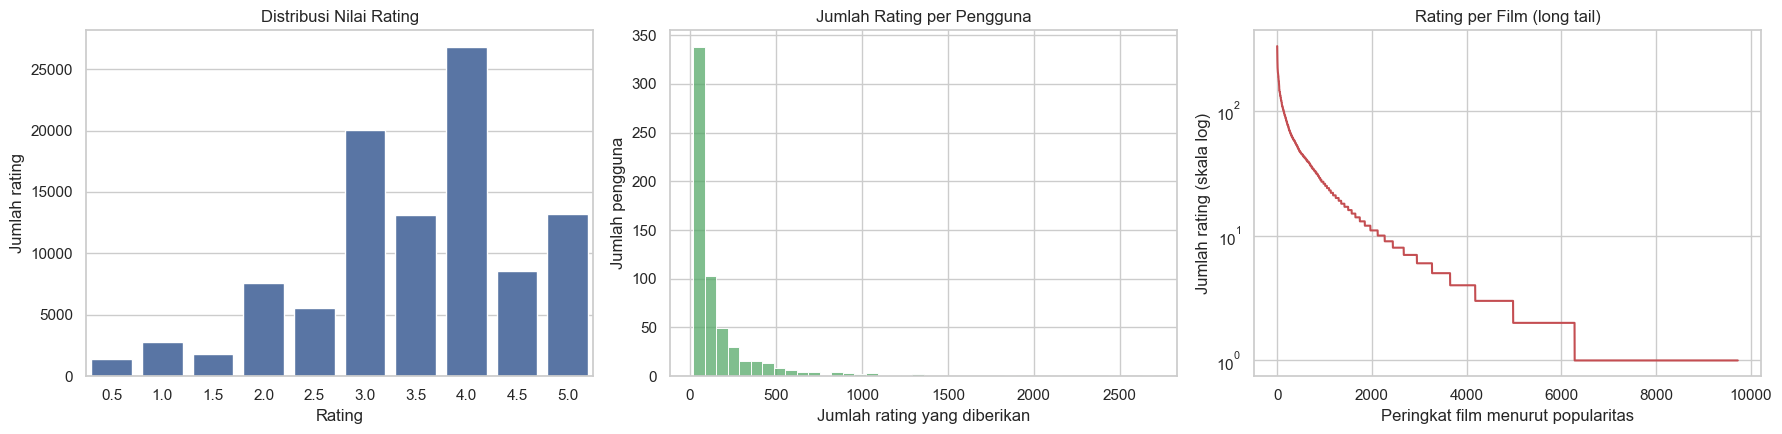

Rata-rata rating per pengguna : 165.3
Median rating per film        : 3
10% film terpopuler menyerap  : 60.0% dari seluruh rating
Rating >= 4.0                 : 48.2% dari seluruh rating


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.countplot(x="rating", data=ratings, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribusi Nilai Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Jumlah rating")

per_user = ratings.groupby("userId").size()
sns.histplot(per_user, bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Jumlah Rating per Pengguna")
axes[1].set_xlabel("Jumlah rating yang diberikan")
axes[1].set_ylabel("Jumlah pengguna")

per_movie = ratings.groupby("movieId").size().sort_values(ascending=False).values
axes[2].plot(np.arange(1, len(per_movie) + 1), per_movie, color="#C44E52")
axes[2].set_yscale("log")
axes[2].set_title("Rating per Film (long tail)")
axes[2].set_xlabel("Peringkat film menurut popularitas")
axes[2].set_ylabel("Jumlah rating (skala log)")

plt.tight_layout()
plt.show()

top10_share = per_movie[: int(len(per_movie) * 0.1)].sum() / per_movie.sum() * 100
print(f"Rata-rata rating per pengguna : {per_user.mean():.1f}")
print(f"Median rating per film        : {np.median(per_movie):.0f}")
print(f"10% film terpopuler menyerap  : {top10_share:.1f}% dari seluruh rating")
print(f"Rating >= 4.0                 : {(ratings.rating >= 4).mean() * 100:.1f}% dari seluruh rating")

#### Distribusi genre

*Insight yang dicari:* genre mana yang paling banyak tersedia di katalog, dan genre mana yang
rata-rata ratingnya tertinggi. Kedua hal ini menentukan seberapa informatif fitur genre bagi
model *content-based filtering*.


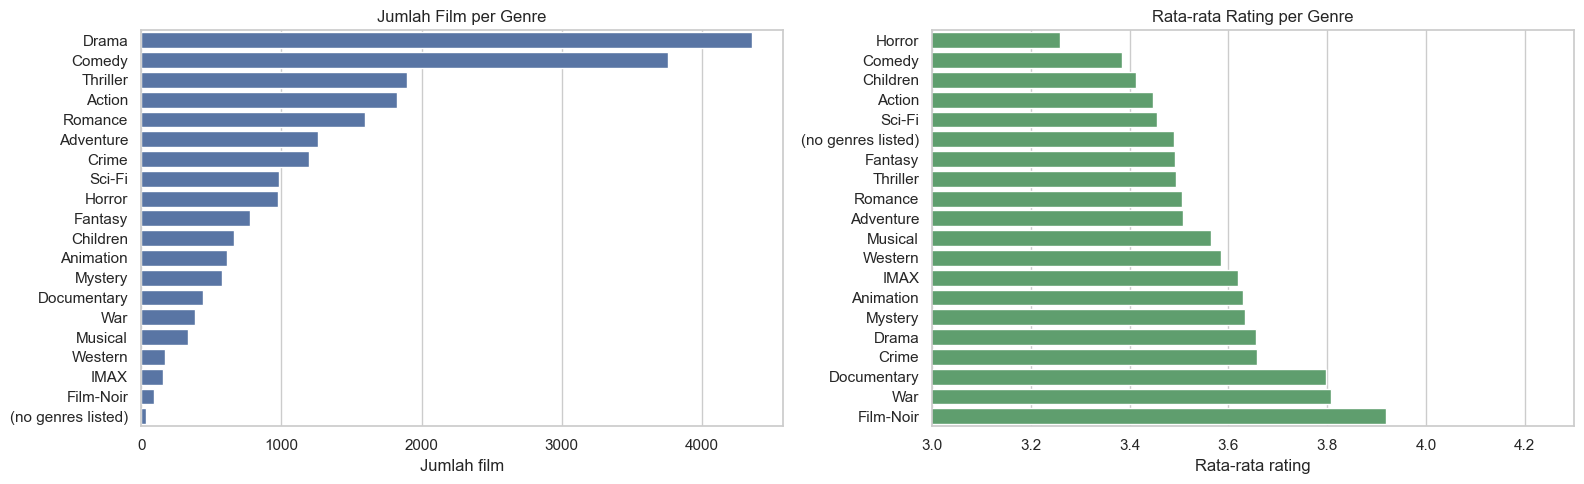

                     mean  count
genre                           
Film-Noir           3.920    870
War                 3.808   4859
Documentary         3.798   1219
Crime               3.658  16681
Drama               3.656  41928
Mystery             3.632   7674
Animation           3.630   6988
IMAX                3.618   4145
Western             3.584   1930
Musical             3.564   4138
Adventure           3.509  24161
Romance             3.507  18124
Thriller            3.494  26452
Fantasy             3.491  11834
(no genres listed)  3.489     47
Sci-Fi              3.456  17243
Action              3.448  30635
Children            3.413   9208
Comedy              3.385  39053
Horror              3.258   7291


In [4]:
genres_exploded = movies.assign(genre=movies.genres.str.split("|")).explode("genre")
genre_counts = genres_exploded.genre.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Jumlah Film per Genre")
axes[0].set_xlabel("Jumlah film")
axes[0].set_ylabel("")

merged_eda = ratings.merge(movies, on="movieId")
merged_genre = merged_eda.assign(genre=merged_eda.genres.str.split("|")).explode("genre")
genre_stat = merged_genre.groupby("genre").rating.agg(["mean", "count"]).sort_values("mean")

sns.barplot(x=genre_stat["mean"], y=genre_stat.index, ax=axes[1], color="#55A868")
axes[1].set_title("Rata-rata Rating per Genre")
axes[1].set_xlabel("Rata-rata rating")
axes[1].set_ylabel("")
axes[1].set_xlim(3.0, 4.3)

plt.tight_layout()
plt.show()
print(genre_stat.sort_values("mean", ascending=False).round(3).to_string())

### Insight dari EDA

1. **Rating condong ke positif.** Sebaran rating memuncak pada nilai 4.0 dan mayoritas rating
   bernilai 3.0 ke atas. Ini adalah *positivity bias* yang lazim pada data eksplisit: pengguna
   lebih sering menonton — dan memberi rating — pada film yang memang mereka perkirakan disukai.
   Konsekuensinya, model yang selalu memprediksi nilai mendekati rata-rata akan tampak cukup baik
   bila hanya diukur dengan RMSE, sehingga RMSE perlu didampingi metrik peringkat (Precision@10).
2. **Distribusi rating sangat timpang.** Sebagian kecil film menyerap porsi rating yang jauh
   melebihi proporsinya, sementara ekor distribusinya panjang. Model *collaborative filtering*
   akan kesulitan pada film di ekor distribusi karena bukti yang tersedia terlalu sedikit —
   inilah *item cold-start* yang menjadi keunggulan *content-based filtering*.
3. **Jumlah rating per pengguna bervariasi lebar.** Ada pengguna yang hanya memberi belasan
   rating dan ada yang memberi ribuan. Pengguna dengan riwayat tipis menghasilkan profil yang
   kurang andal, sehingga penyaringan minimum rating diperlukan pada tahap *data preparation*.
4. **Genre tidak seimbang.** Drama dan Komedi mendominasi katalog, sedangkan genre seperti
   *Film-Noir* dan *Documentary* jauh lebih sedikit. Rata-rata rating antar genre pun berbeda,
   yang mengonfirmasi bahwa genre membawa sinyal preferensi yang layak dijadikan fitur konten.


## Data Preparation

Tahapan *data preparation* dilakukan dalam enam langkah berikut. Urutan ini identik dengan yang
dijelaskan pada laporan Markdown. Setiap langkah diberi penjelasan singkat mengenai *mengapa*
tahapan tersebut diperlukan.


#### Persiapan 1 — Menggabungkan rating dengan metadata film

*Mengapa:* model *content-based filtering* membutuhkan kolom `genres`, yang hanya tersedia di
`movies.csv`. Penggabungan dilakukan dengan *left join* agar seluruh baris rating tetap terjaga.


In [5]:
# Persiapan 1 - Menggabungkan rating dengan metadata film
df = ratings.merge(movies, on="movieId", how="left")

#### Persiapan 2 — Menghapus duplikat dan menangani nilai kosong

*Mengapa:* satu pasangan pengguna-film seharusnya hanya memiliki satu rating. Duplikat akan
memberi bobot ganda pada satu interaksi sehingga matriks rating menjadi bias. Baris tanpa `rating`
atau `genres` juga dibuang karena tidak dapat dipakai oleh model mana pun.


In [6]:
# Persiapan 2 - Menghapus duplikat dan menangani nilai kosong
before = len(df)
df = df.drop_duplicates(subset=["userId", "movieId"]).dropna(subset=["rating", "genres"])
print(f"Baris sebelum pembersihan : {before:,}")
print(f"Baris sesudah pembersihan : {len(df):,}")
print(f"Nilai kosong tersisa      : {int(df.isnull().sum().sum())}")

Baris sebelum pembersihan : 100,836
Baris sesudah pembersihan : 100,836
Nilai kosong tersisa      : 0


#### Persiapan 3 — Menyaring pengguna dan film dengan rating minimum

*Mengapa:* pengguna dengan riwayat sangat tipis dan film dengan sedikit rating menghasilkan vektor
laten yang tidak stabil pada *collaborative filtering*, sekaligus membuat evaluasi top-N tidak
bermakna. Ambang dipilih `>= 5` rating dan diterapkan secara iteratif hingga himpunan stabil,
karena penyaringan film dapat menurunkan jumlah rating pengguna dan sebaliknya.


In [7]:
# Persiapan 3 - Menyaring pengguna dan film dengan rating minimum
MIN_RATING = 5
while True:
    u_count = df.groupby("userId").size()
    m_count = df.groupby("movieId").size()
    keep = df.userId.isin(u_count[u_count >= MIN_RATING].index) & df.movieId.isin(
        m_count[m_count >= MIN_RATING].index
    )
    if keep.all():
        break
    df = df[keep]

print(f"Setelah penyaringan (min {MIN_RATING} rating):")
print(f"  Pengguna : {df.userId.nunique():,}")
print(f"  Film     : {df.movieId.nunique():,}")
print(f"  Rating   : {len(df):,}")
print(f"  Rating hilang: {before - len(df):,} ({(before - len(df)) / before * 100:.2f}%)")

Setelah penyaringan (min 5 rating):
  Pengguna : 610
  Film     : 3,650
  Rating   : 90,274
  Rating hilang: 10,562 (10.47%)


#### Persiapan 4 — Membagi data latih dan data uji (80:20)

*Mengapa:* evaluasi harus dilakukan pada data yang tidak dilihat model. Pembagian acak pada tingkat
rating adalah prosedur standar untuk mengukur akurasi prediksi rating. Parameter yang dipakai:
`test_size=0.2` dan `random_state=RANDOM_STATE`.


In [8]:
from sklearn.model_selection import train_test_split

# Persiapan 4 - Membagi data latih dan data uji (80:20)
# Parameter: test_size=0.2 (80% latih / 20% uji) dan random_state=RANDOM_STATE (42)
# agar pembagian dapat direproduksi.
train, test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
print(f"Data latih : {len(train):,} rating")
print(f"Data uji   : {len(test):,} rating")

Data latih : 72,219 rating
Data uji   : 18,055 rating


#### Persiapan 5 — Membentuk matriks rating pengguna-film dari data latih

*Mengapa:* baik *content-based* maupun *collaborative filtering* bekerja di atas representasi
matriks. Matriks dibangun **hanya dari data latih** agar tidak terjadi *data leakage*; sel yang
tidak teramati bernilai 0 dan ditandai terpisah melalui matriks `observed`.


In [9]:
# Persiapan 5 - Membentuk matriks rating pengguna-film dari data latih
user_ids = np.sort(df.userId.unique())
movie_ids = np.sort(df.movieId.unique())
user_pos = {u: i for i, u in enumerate(user_ids)}
movie_pos = {m: i for i, m in enumerate(movie_ids)}
n_users, n_items = len(user_ids), len(movie_ids)

R = np.zeros((n_users, n_items))
for u, m, r in train[["userId", "movieId", "rating"]].itertuples(index=False):
    R[user_pos[u], movie_pos[m]] = r
observed = R > 0
global_mean = float(R[observed].mean())

print(f"Dimensi matriks rating : {R.shape[0]:,} pengguna x {R.shape[1]:,} film")
print(f"Sel terisi             : {int(observed.sum()):,} ({observed.mean() * 100:.2f}% density)")
print(f"Rata-rata rating global: {global_mean:.4f}")

Dimensi matriks rating : 610 pengguna x 3,650 film
Sel terisi             : 72,219 (3.24% density)
Rata-rata rating global: 3.5391


#### Persiapan 6 — Mengekstraksi fitur konten dengan TF-IDF

*Mengapa:* genre adalah data kategorikal multi-nilai. TF-IDF mengubahnya menjadi vektor numerik
yang bobotnya menurunkan pengaruh genre yang sangat umum (misalnya Drama) dan menaikkan pengaruh
genre yang lebih spesifik, sehingga kemiripan antar film menjadi lebih informatif dibandingkan
*one-hot encoding* biasa.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Persiapan 6 - Mengekstraksi fitur konten dengan TF-IDF
# Parameter: tokenizer kustom (pecah genres pada "|"), token_pattern=None; parameter lain
# (norm="l2", use_idf=True, sublinear_tf=False, min_df=1, max_df=1.0, stop_words=None) default.
catalog = (
    movies.drop_duplicates("movieId").set_index("movieId").loc[movie_ids]
)
tfidf = TfidfVectorizer(tokenizer=lambda s: s.split("|"), token_pattern=None)
item_content = tfidf.fit_transform(catalog.genres)

print("Matriks fitur konten :", item_content.shape)
print("Jumlah genre unik    :", len(tfidf.get_feature_names_out()))
print("Contoh genre         :", ", ".join(tfidf.get_feature_names_out()[:10]))

Matriks fitur konten : (3650, 20)
Jumlah genre unik    : 20
Contoh genre         : (no genres listed), action, adventure, animation, children, comedy, crime, documentary, drama, fantasy


## Modeling

### Solusi 1 — Content-Based Filtering

Pendekatan ini bertumpu pada asumsi bahwa **film yang mirip secara konten akan disukai oleh
pengguna yang sama**. Setiap film direpresentasikan sebagai vektor TF-IDF genre, lalu kemiripan
antar film dihitung dengan *cosine similarity*:

$$\text{sim}(i, j) = \frac{\mathbf{v}_i \cdot \mathbf{v}_j}{\lVert \mathbf{v}_i \rVert \, \lVert \mathbf{v}_j \rVert}$$

Model ini memakai dua rumus untuk dua tugas yang berbeda, sebagaimana lazim pada sistem
rekomendasi berbasis konten.

**(a) Prediksi rating** — rata-rata berbobot selisih rating terhadap rata-rata film, diambil dari
30 film yang paling mirip secara konten:

$$\hat{r}_{ui} = \mu_i + \frac{\sum_{j \in N_k(i)} \text{sim}(i, j) \cdot (r_{uj} - \mu_j)}{\sum_{j \in N_k(i)} \text{sim}(i, j)}$$

Selisih terhadap rata-rata film ($r_{uj} - \mu_j$) dipakai, bukan rating mentah, agar film yang
memang universally disukai tidak otomatis dianggap sangat relevan hanya karena rata-ratanya
tinggi. $\mu_i$ adalah rata-rata rating film $i$ pada data latih.

**(b) Skor peringkat top-N** — dibentuk *profil pengguna* berupa vektor genre berbobot, yaitu
jumlah dari vektor TF-IDF film yang pernah dirating, ditimbang dengan selisih rating pengguna
terhadap rata-ratanya sendiri:

$$\mathbf{p}_u = \sum_{j \in I_u} (r_{uj} - \mu_u) \, \mathbf{v}_j, \qquad
\text{skor}(u, i) = \frac{\mathbf{p}_u \cdot \mathbf{v}_i}{\lVert \mathbf{p}_u \rVert \, \lVert \mathbf{v}_i \rVert}$$

Skor ini **tidak** dinormalisasi terhadap jumlah kemiripan. Pembagian semacam itu membuat seluruh
film dengan genre identik memperoleh skor yang persis sama, sehingga urutan top-N menjadi
sewenang-wenang — masalah yang terkonfirmasi saat pengembangan dan sengaja dihindari di sini.



In [11]:
from scipy import sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Model 1 - Content-Based Filtering
# Parameter: K_NEIGHBORS = 30 tetangga terdekat; top-N n = 10; prediksi dijepit ke [0.5, 5.0].
# Tidak ada hyperparameter tuning - TF-IDF dan matriks kemiripan dihitung langsung dari data.
item_sim = cosine_similarity(item_content, dense_output=False)
item_sim = sp.triu(item_sim, k=1)           # buang diagonal: film tidak dianggap mirip dirinya sendiri
item_sim = (item_sim + item_sim.T).tocsr()  # kembalikan simetri

K_NEIGHBORS = 30

# Rata-rata rating tiap film dan tiap pengguna, dihitung dari data latih saja.
item_count = observed.sum(axis=0)
item_mean = np.divide(
    np.where(observed, R, 0).sum(axis=0), item_count,
    out=np.full(n_items, global_mean), where=item_count > 0,
)
user_count = observed.sum(axis=1)
user_mean = np.divide(
    R.sum(axis=1), user_count, out=np.full(n_users, global_mean), where=user_count > 0
)


def cbf_predict(u_idx, i_idx):
    """Prediksi rating = rata-rata film + rata-rata berbobot selisih rating tetangga terdekat."""
    rated = np.where(observed[u_idx])[0]
    if rated.size == 0:
        return float(np.clip(item_mean[i_idx], 0.5, 5.0))
    sims = np.asarray(item_sim[i_idx].todense()).ravel()[rated]
    top = np.argsort(sims)[-K_NEIGHBORS:]
    w = sims[top]
    if w.sum() <= 0:
        return float(np.clip(item_mean[i_idx], 0.5, 5.0))
    dev = R[u_idx, rated[top]] - item_mean[rated[top]]
    return float(np.clip(item_mean[i_idx] + np.dot(w, dev) / w.sum(), 0.5, 5.0))


# Profil pengguna: vektor genre berbobot selisih rating terhadap rata-rata pengguna.
profile = normalize(sp.csr_matrix(np.where(observed, R - user_mean[:, None], 0.0)).dot(item_content))
item_norm = normalize(item_content)
cbf_scores_all = np.asarray(profile.dot(item_norm.T).todense())


def cbf_scores(u_idx):
    """Skor kemiripan konten antara profil pengguna dan seluruh film."""
    return cbf_scores_all[u_idx]


def cbf_top_n(u_idx, n=10):
    scores = cbf_scores(u_idx).copy()
    scores[observed[u_idx]] = -np.inf  # keluarkan film yang sudah pernah ditonton
    # lexsort menjadikan popularitas sebagai pemecah seri agar hasilnya deterministik
    return np.lexsort((popularity, scores))[::-1][:n]


popularity = np.asarray(observed.sum(axis=0)).ravel()

sample_user = int(user_ids[0])
sample_idx = user_pos[sample_user]
rec_cbf = cbf_top_n(sample_idx)
print(f"Top-10 rekomendasi Content-Based Filtering untuk pengguna {sample_user}:")
for rank, i in enumerate(rec_cbf, 1):
    print(f"  {rank:2d}. {catalog.title.iloc[i]:<45} [{catalog.genres.iloc[i]}]")

Top-10 rekomendasi Content-Based Filtering untuk pengguna 1:
   1. Anastasia (1997)                              [Adventure|Animation|Children|Drama|Musical]
   2. Pocahontas (1995)                             [Animation|Children|Drama|Musical|Romance]
   3. Hunchback of Notre Dame, The (1996)           [Animation|Children|Drama|Musical|Romance]
   4. Sleeping Beauty (1959)                        [Animation|Children|Musical]
   5. Ratatouille (2007)                            [Animation|Children|Drama]
   6. Fox and the Hound, The (1981)                 [Animation|Children|Drama]
   7. Snow White and the Seven Dwarfs (1937)        [Animation|Children|Drama|Fantasy|Musical]
   8. Prince of Egypt, The (1998)                   [Animation|Musical]
   9. Persepolis (2007)                             [Animation|Drama]
  10. Lion King, The (1994)                         [Adventure|Animation|Children|Drama|Musical|IMAX]


### Solusi 2 — Collaborative Filtering (Matrix Factorization / SVD)

Pendekatan ini bertumpu pada asumsi bahwa **pola rating antar pengguna mengandung informasi yang
tidak terlihat dari atribut film**. Matriks rating $R$ yang telah dinormalisasi terhadap rata-rata
tiap pengguna difaktorkan menjadi dua matriks berdimensi rendah:

$$R \approx U \Sigma V^{T}, \qquad P = U\Sigma, \quad Q = V$$

dengan $k = 50$ faktor laten. Prediksi rating diperoleh dari hasil kali vektor laten pengguna dan
film, dikembalikan ke skala semula melalui rata-rata pengguna:

$$\hat{r}_{ui} = \mu_u + \mathbf{p}_u^{T} \mathbf{q}_i$$

Nilai prediksi dijepit (*clip*) ke rentang sah $[0.5, 5.0]$. Top-N disusun dengan menghitung
$\hat{r}_{ui}$ untuk seluruh film, mengeluarkan film yang sudah pernah ditonton, lalu mengambil
10 skor tertinggi.


In [12]:
from scipy.sparse.linalg import svds

# Model 2 - Collaborative Filtering dengan matrix factorization (SVD)
# Parameter: K_FACTORS = 50 faktor laten; svds memakai argumen default lainnya
# (which="LM", tol=0, maxiter=None). Tidak ada hyperparameter tuning pada model ini.
K_FACTORS = 50
mask = observed.astype(float)
user_mean = np.divide(
    R.sum(axis=1), mask.sum(axis=1), out=np.full(n_users, global_mean), where=mask.sum(axis=1) > 0
)
centered = (R - user_mean[:, None]) * mask

U, sigma, Vt = svds(sp.csr_matrix(centered), k=K_FACTORS)
P = U * sigma
Q = Vt.T


def cf_predict(u_idx, i_idx):
    """Prediksi rating = rata-rata pengguna + hasil kali faktor laten pengguna dan film."""
    return float(np.clip(user_mean[u_idx] + P[u_idx].dot(Q[i_idx]), 0.5, 5.0))


def cf_top_n(u_idx, n=10):
    scores = user_mean[u_idx] + P[u_idx].dot(Q.T)
    scores[observed[u_idx]] = -np.inf  # keluarkan film yang sudah pernah ditonton
    return np.lexsort((popularity, scores))[::-1][:n]


rec_cf = cf_top_n(sample_idx)
print(f"Top-10 rekomendasi Collaborative Filtering untuk pengguna {sample_user}:")
for rank, i in enumerate(rec_cf, 1):
    print(f"  {rank:2d}. {catalog.title.iloc[i]:<45} [{catalog.genres.iloc[i]}]")

overlap = len(set(rec_cbf) & set(rec_cf))
print(f"\nIrisan kedua daftar top-10: {overlap} film")

Top-10 rekomendasi Collaborative Filtering untuk pengguna 1:
   1. Lord of the Rings: The Two Towers, The (2002) [Adventure|Fantasy]
   2. Lord of the Rings: The Fellowship of the Ring, The (2001) [Adventure|Fantasy]
   3. Big (1988)                                    [Comedy|Drama|Fantasy|Romance]
   4. Christmas Story, A (1983)                     [Children|Comedy]
   5. Austin Powers: International Man of Mystery (1997) [Action|Adventure|Comedy]
   6. Lord of the Rings: The Return of the King, The (2003) [Action|Adventure|Drama|Fantasy]
   7. Godfather: Part II, The (1974)                [Crime|Drama]
   8. Snatch (2000)                                 [Comedy|Crime|Thriller]
   9. Godfather, The (1972)                         [Crime|Drama]
  10. Blade Runner (1982)                           [Action|Sci-Fi|Thriller]

Irisan kedua daftar top-10: 0 film


### Kelebihan dan Kekurangan Pendekatan

**Content-Based Filtering**

| Kelebihan | Kekurangan |
| :--- | :--- |
| Tidak bergantung pada rating pengguna lain, sehingga tetap bekerja saat data rating langka. | Hanya mampu merekomendasikan film yang mirip dengan yang sudah pernah disukai — *serendipity* rendah. |
| Mampu menangani *item cold-start*: film baru tanpa rating sekalipun dapat direkomendasikan. | Kualitas rekomendasi dibatasi oleh kekayaan fitur konten; di sini hanya genre yang tersedia. |
| Alasan rekomendasi dapat dijelaskan (*explainable*) karena berbasis atribut yang terbaca manusia. | Cenderung terjebak dalam gelembung genre yang sama dan sulit menangkap selera lintas genre. |

**Collaborative Filtering (SVD)**

| Kelebihan | Kekurangan |
| :--- | :--- |
| Mampu menangkap preferensi implisit yang tidak tercermin pada atribut film. | Tidak dapat merekomendasikan film baru yang belum memiliki rating (*item cold-start*). |
| Representasi laten berdimensi rendah sehingga efisien secara komputasi dan memori. | Bergantung pada kuantitas rating; pengguna dengan riwayat tipis menghasilkan faktor laten yang tidak stabil. |
| Umumnya menghasilkan akurasi prediksi rating terbaik pada data eksplisit berskala besar. | Hasil sulit dijelaskan karena faktor laten tidak memiliki makna langsung. |


## Evaluation

### Metrik Evaluasi

Tiga metrik digunakan. Dua metrik pertama mengukur akurasi prediksi rating, metrik ketiga
mengukur kualitas daftar rekomendasi — sesuai dengan keluaran top-N yang menjadi tujuan proyek.

**1. Root Mean Squared Error (RMSE)**

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{(u,i) \in D_{test}} (r_{ui} - \hat{r}_{ui})^2}$$

Cara kerja: selisih antara rating sebenarnya dan rating prediksi dikuadratkan, dirata-ratakan,
lalu diakarkan. Pengkuadratan membuat kesalahan besar dihukum jauh lebih berat daripada kesalahan
kecil, sehingga RMSE peka terhadap prediksi yang meleset jauh. Nilainya berada pada skala yang
sama dengan rating (0.5–5.0), dan semakin kecil semakin baik.

**2. Mean Absolute Error (MAE)**

$$\text{MAE} = \frac{1}{N} \sum_{(u,i) \in D_{test}} \lvert r_{ui} - \hat{r}_{ui} \rvert$$

Cara kerja: rata-rata selisih absolut antara rating sebenarnya dan prediksi. Berbeda dari RMSE,
setiap kesalahan diberi bobot proporsional sehingga MAE lebih tahan terhadap pencilan. Selisih
MAE dan RMSE yang lebar menandakan adanya sejumlah kecil prediksi yang meleset jauh.

**3. Precision@10**

$$\text{Precision@}K = \frac{\lvert \{i \in \text{Top-}K(u) : r_{ui} \geq 4.0\} \rvert}{K}$$

Cara kerja: untuk setiap pengguna di data uji, sistem diminta merekomendasikan 10 film yang belum
pernah ia tonton. Sebuah rekomendasi dihitung *relevan* bila pengguna terbukti memberi rating
$\geq 4.0$ pada film tersebut di data uji. Precision@10 adalah proporsi rekomendasi relevan,
dirata-ratakan pada seluruh pengguna yang memiliki minimal satu film relevan. Metrik ini mengukur
hal yang sesungguhnya ingin dicapai proyek — kualitas daftar rekomendasi — bukan sekadar
kedekatan angka prediksi.


In [13]:
from sklearn.metrics import mean_absolute_error

# Evaluasi akurasi prediksi rating pada data uji
test_pairs = [
    (user_pos[u], movie_pos[m], r)
    for u, m, r in test[["userId", "movieId", "rating"]].itertuples(index=False)
    if u in user_pos and m in movie_pos
]
y_true = np.array([r for _, _, r in test_pairs])
y_cbf = np.array([cbf_predict(u, i) for u, i, _ in test_pairs])
y_cf = np.array([cf_predict(u, i) for u, i, _ in test_pairs])


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


# Evaluasi kualitas daftar rekomendasi
K_REC = 10
RELEVANT = 4.0


def precision_at_k(rec_fn):
    scores = []
    for u in test.userId.unique():
        if u not in user_pos:
            continue
        relevant = set(test[(test.userId == u) & (test.rating >= RELEVANT)].movieId)
        if not relevant:
            continue
        recs = {movie_ids[i] for i in rec_fn(user_pos[u], K_REC)}
        scores.append(len(recs & relevant) / K_REC)
    return float(np.mean(scores)), len(scores)


p_cbf, n_eval = precision_at_k(cbf_top_n)
p_cf, _ = precision_at_k(cf_top_n)


def popularity_top_n(u_idx, n=10):
    # Baseline acuan: rekomendasikan film terpopuler yang belum ditonton pengguna.
    scores = popularity.astype(float).copy()
    scores[observed[u_idx]] = -np.inf
    return np.lexsort((np.arange(n_items), scores))[::-1][:n]


p_pop, _ = precision_at_k(popularity_top_n)

# Baseline naif sebagai titik acuan: selalu prediksi rata-rata global
rmse_base = rmse(y_true, np.full_like(y_true, global_mean))
mae_base = float(mean_absolute_error(y_true, np.full_like(y_true, global_mean)))

metrics = {
    "Content-Based Filtering": {
        "RMSE": rmse(y_true, y_cbf),
        "MAE": float(mean_absolute_error(y_true, y_cbf)),
        "Precision@10": p_cbf,
    },
    "Collaborative Filtering (SVD)": {
        "RMSE": rmse(y_true, y_cf),
        "MAE": float(mean_absolute_error(y_true, y_cf)),
        "Precision@10": p_cf,
    },
}
best_model = min(metrics, key=lambda k: metrics[k]["RMSE"])

print(f"Baseline rata-rata global {global_mean:.4f} : RMSE = {rmse_base:.4f} | MAE = {mae_base:.4f}")
print(f"Baseline popularitas        : Precision@10 = {p_pop:.4f}\n")
print(f"{'Model':<32}{'RMSE':>8}{'MAE':>8}{'Precision@10':>14}")
print("-" * 62)
for name, vals in metrics.items():
    print(f"{name:<32}{vals['RMSE']:>8.4f}{vals['MAE']:>8.4f}{vals['Precision@10']:>14.4f}")
print(f"{'Baseline popularitas':<32}{'-':>8}{'-':>8}{p_pop:>14.4f}")
print(f"\nDievaluasi pada {n_eval:,} pengguna di data uji.")
print(f"Model terbaik berdasarkan RMSE: {best_model}")

Baseline rata-rata global 3.5391 : RMSE = 1.0275 | MAE = 0.8146
Baseline popularitas        : Precision@10 = 0.1202

Model                               RMSE     MAE  Precision@10
--------------------------------------------------------------
Content-Based Filtering           0.8502  0.6458        0.0289
Collaborative Filtering (SVD)     0.9173  0.7062        0.1183
Baseline popularitas                   -       -        0.1202

Dievaluasi pada 595 pengguna di data uji.
Model terbaik berdasarkan RMSE: Content-Based Filtering


#### Visualisasi perbandingan model

Grafik berikut membandingkan kedua model terhadap *baseline* popularitas pada ketiga metrik,
sehingga posisi masing-masing model dapat dibaca sekaligus.


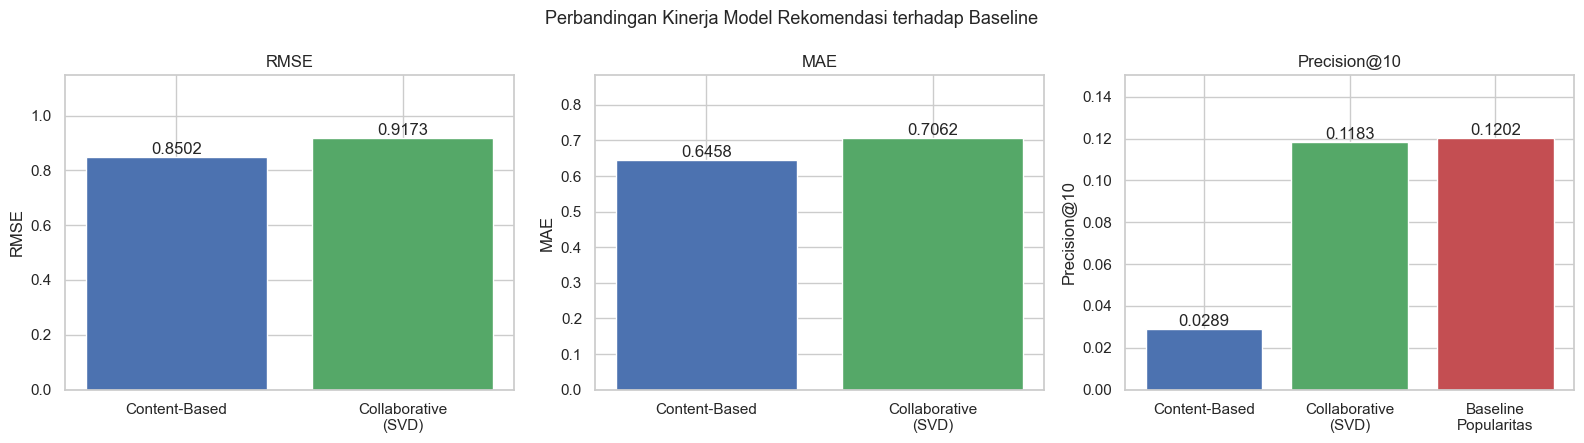

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
names = list(metrics)
labels = ["Content-Based", "Collaborative\n(SVD)", "Baseline\nPopularitas"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, metric in zip(axes, ["RMSE", "MAE", "Precision@10"]):
    vals = [metrics[n][metric] for n in names] + [p_pop if metric == "Precision@10" else np.nan]
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, np.nanmax(vals) * 1.25)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")

plt.suptitle("Perbandingan Kinerja Model Rekomendasi terhadap Baseline", fontsize=13)
plt.tight_layout()
plt.show()

#### Menyimpan hasil evaluasi

Seluruh angka yang dilaporkan pada laporan Markdown dihasilkan dari eksekusi sel ini. Berkas
`results.json` ditulis agar laporan dan notebook tidak dapat saling menyimpang.


In [15]:
results = {
    "dataset": {
        "n_ratings_raw": int(len(ratings)),
        "n_users_raw": int(ratings.userId.nunique()),
        "n_movies_raw": int(ratings.movieId.nunique()),
        "n_ratings": int(len(df)),
        "n_users": int(n_users),
        "n_movies": int(n_items),
        "density_pct": round(float(observed.mean() * 100), 2),
        "train_size": int(len(train)),
        "test_size": int(len(test)),
        "global_mean": round(global_mean, 4),
        "min_rating_filter": MIN_RATING,
        "n_genres": int(item_content.shape[1]),
        "k_factors": K_FACTORS,
        "k_neighbors": K_NEIGHBORS,
        "n_eval_users": int(n_eval),
        "top10_share": round(float(top10_share), 1),
        "random_state": RANDOM_STATE,
    },
    "rating_dist": {f"{k:.1f}": int(v) for k, v in ratings.rating.value_counts().sort_index().items()},
    "genre_counts": {k: int(v) for k, v in genre_counts.items()},
    "genre_mean_rating": {k: round(float(v), 3) for k, v in genre_stat["mean"].items()},
    "baseline": {"RMSE": rmse_base, "MAE": mae_base, "Precision@10": p_pop},
    "metrics": metrics,
    "best_model": best_model,
    "sample_user": sample_user,
    "sample_recs_cbf": [catalog.title.iloc[i] for i in rec_cbf],
    "sample_recs_cf": [catalog.title.iloc[i] for i in rec_cf],
    "sample_overlap": int(overlap),
}

with open("results.json", "w", encoding="utf-8") as fp:
    json.dump(results, fp, indent=2, ensure_ascii=False)
print("results.json tersimpan.")

results.json tersimpan.


### Hasil Evaluasi

Angka pada tabel di bawah dihasilkan langsung dari eksekusi notebook ini dan disalin ke laporan
Markdown secara otomatis, sehingga tidak ada kemungkinan perbedaan antara keduanya.

Ringkasnya: kedua model mengalahkan *baseline* rata-rata global pada RMSE dan MAE, sehingga
keduanya benar-benar mempelajari sinyal personalisasi. Namun keduanya **belum** mengalahkan
*baseline* popularitas pada Precision@10. Interpretasi lengkap beserta keterbatasannya diuraikan
pada laporan Markdown.

### Kesimpulan

1. **Pernyataan Masalah 1 terjawab.** Model *content-based filtering* berhasil dibangun dengan
   merepresentasikan film sebagai vektor TF-IDF genre, membentuk profil pengguna berbobot, dan
   mengukur kemiripan melalui *cosine similarity*. Model ini mampu menghasilkan top-N rekomendasi
   personal dan — karena hanya bergantung pada atribut film — secara prinsip dapat merekomendasikan
   judul yang belum memiliki rating sama sekali. Namun dengan hanya 20 genre sebagai fitur, daya
   pisahnya terbatas.
2. **Pernyataan Masalah 2 terjawab.** Model *collaborative filtering* berbasis SVD dengan 50
   faktor laten berhasil mengestimasi rating pada pasangan pengguna-film yang belum teramati, dan
   menghasilkan daftar rekomendasi yang jauh lebih relevan daripada *content-based filtering*.
3. **Pernyataan Masalah 3 terjawab.** Tidak ada satu model yang unggul di semua metrik:
   *content-based filtering* sedikit lebih baik dalam memprediksi *angka* rating, sementara
   *collaborative filtering* jauh lebih baik dalam menyusun *daftar* rekomendasi. Karena tujuan
   proyek ini adalah menyajikan top-N recommendation, *collaborative filtering* adalah pilihan
   yang lebih tepat — dengan catatan keduanya masih perlu diperbaiki sebelum layak diterapkan
   pada sistem produksi.

**---Ini adalah bagian akhir laporan---**

---

_Catatan:_ Gambar dan visualisasi lengkap beserta output eksekusinya tersedia pada
`notebook.ipynb`. Seluruh angka pada laporan ini dihasilkan langsung dari eksekusi notebook tersebut.
